# Assignment — RSA: Models vs. STG

Reusable RSA toolbox carried over from the practical (numpy / scipy / matplotlib only), plus a skeleton for the assignment.

RSA recap: each system → `(n_items, n_features)` → RDM `(n_items, n_items)` → correlate the **upper triangles (no diagonal)** of the RDMs.

In [2]:
%pip install torch torchaudio soundfile --q

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=3, suppress=True)

DATA_DIR = Path("data")                    # adjust to where you unpacked the data
MODEL_DIR = Path("models")  # adjust to where the checkpoints live

## RSA toolbox

In [4]:
def compute_rdm(patterns: np.ndarray, metric: str = "euclidean") -> np.ndarray:
    """RDM from patterns of shape (n_items, ...). Extra dims (e.g. conv channels x freq x time)
    are flattened. metric = "euclidean" | "correlation"."""
    patterns = np.asarray(patterns, dtype=float).reshape(len(patterns), -1)

    if metric == "euclidean":
        sq = np.sum(patterns ** 2, axis=1)
        rdm = np.sqrt(np.maximum(sq[:, None] + sq[None, :] - 2 * patterns @ patterns.T, 0))
        np.fill_diagonal(rdm, 0)
        return rdm

    if metric == "correlation":
        rdm = 1 - np.corrcoef(patterns)
        np.fill_diagonal(rdm, 0)
        return rdm

    raise ValueError(f"Unknown metric: {metric}")


def upper_triangle(rdm: np.ndarray) -> np.ndarray:
    """Off-diagonal upper-triangular entries as a 1D vector."""
    i, j = np.triu_indices(rdm.shape[0], k=1)
    return rdm[i, j]


def compare_rdms(rdm_a: np.ndarray, rdm_b: np.ndarray, method: str = "pearson") -> float:
    """Correlation between the upper triangles of two RDMs. method = "pearson" | "spearman"."""
    a, b = upper_triangle(rdm_a), upper_triangle(rdm_b)
    if method == "pearson":
        return stats.pearsonr(a, b)[0]
    if method == "spearman":
        return stats.spearmanr(a, b)[0]
    raise ValueError(f"Unknown method: {method}")


def compare_to_many(reference_rdm, candidate_rdms: dict, method="pearson") -> list:
    """Returns [(name, score), ...] sorted best -> worst."""
    results = [(name, compare_rdms(reference_rdm, rdm, method)) for name, rdm in candidate_rdms.items()]
    return sorted(results, key=lambda t: t[1], reverse=True)

In [5]:
def mean_ci(scores, confidence=0.95):
    """Returns (mean, ci_low, ci_high) using the t-distribution.
    (util.mean_and_ci does the same job if you prefer the provided helper.)"""
    scores = np.asarray(scores, dtype=float)
    m = scores.mean()
    h = stats.sem(scores) * stats.t.ppf((1 + confidence) / 2, df=len(scores) - 1)
    return m, m - h, m + h

In [6]:
def plot_rdm(rdm, labels=None, title="", ax=None):
    """Heatmap of one RDM. Returns the image object (needed for the colorbar)."""
    if ax is None:
        _, ax = plt.subplots()
    im = ax.imshow(rdm, cmap="viridis")
    if labels is not None:
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=90)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
    ax.set_title(title)
    return im


def plot_rdms(rdms: dict, labels=None):
    """Several RDMs side by side. rdms = {"name": rdm}"""
    fig, axes = plt.subplots(1, len(rdms), figsize=(4 * len(rdms), 4), squeeze=False)
    for ax, (name, rdm) in zip(axes[0], rdms.items()):
        im = plot_rdm(rdm, labels=labels, title=name, ax=ax)
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## Setup — data and models

Check `core.py` for the exact return formats of these helpers before relying on them.

In [7]:
from core import SantoroDataset, MODEL_CLASSES, extract_activations, load_yamnet_activations

dataset = SantoroDataset()

from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

# brain rdm

brain = dataset.brain_responses.numpy()
rdm_brain = compute_rdm(brain, metric="euclidean")

print(brain.shape)
print(rdm_brain.shape)
print(np.allclose(rdm_brain, rdm_brain.T))

# TODO: build a DataLoader over `dataset` (no shuffling, so stimulus order stays fixed)
# TODO: pull out the STG activity -> rdm_brain = compute_rdm(stg, metric)

(288, 5521)
(288, 288)
True


## Part I — RSA: models vs. brain

1. **Untrained models**: `MODEL_CLASSES[name](num_classes=50)`, no checkpoint → per-layer RDMs
2. **Trained models**: same, then load weights from `MODEL_DIR` → per-layer RDMs
3. **YAMNet**: `load_yamnet_activations()` → per-layer RDMs
4. Compare every layer to the brain RDM (try several metric × method combinations)
5. Stats: mean + 95% CI across model copies; paired tests where models share the same brain RDM

In [8]:
# Untrained models


def get_rsa_scores(model):
    activations = extract_activations(dataloader, model)
    scores = {}

    for layer, act in activations.items():
        rdm = compute_rdm(act.numpy(), metric="euclidean")
        scores[layer] = compare_rdms(rdm_brain, rdm, method="pearson")

    return scores

import torch

untrained_scores = []

for seed in range(5):
    torch.manual_seed(seed)

    model = MODEL_CLASSES["waveform"](num_classes=50)
    scores = get_rsa_scores(model)

    untrained_scores.append(scores)

    print("\nuntrained", seed)
    for layer, score in scores.items():
        print(layer, round(score, 4))


untrained 0
hidden_layers.0 -0.0249
hidden_layers.1 -0.0209
hidden_layers.2 -0.041
hidden_layers.3 -0.0243
hidden_layers.4 -0.0036
classifier 0.0104

untrained 1
hidden_layers.0 -0.0254
hidden_layers.1 -0.019
hidden_layers.2 -0.0247
hidden_layers.3 -0.0206
hidden_layers.4 -0.0243
classifier -0.004

untrained 2
hidden_layers.0 -0.0203
hidden_layers.1 -0.0269
hidden_layers.2 -0.0215
hidden_layers.3 -0.0406
hidden_layers.4 -0.0375
classifier -0.0327

untrained 3
hidden_layers.0 -0.0252
hidden_layers.1 -0.0233
hidden_layers.2 -0.0355
hidden_layers.3 -0.0266
hidden_layers.4 -0.0421
classifier -0.0315

untrained 4
hidden_layers.0 -0.0131
hidden_layers.1 -0.0248
hidden_layers.2 -0.0149
hidden_layers.3 0.0196
hidden_layers.4 0.0055
classifier 0.019


In [9]:
# Trained models
trained_scores = []

files = sorted(MODEL_DIR.glob("waveform_run*_best.pt"))

for file in files:
    model = MODEL_CLASSES["waveform"](num_classes=50)

    weights = torch.load(file, map_location="cpu")
    model.load_state_dict(weights)

    scores = get_rsa_scores(model)
    trained_scores.append(scores)

    print("\n", file.name)
    for layer, score in scores.items():
        print(layer, round(score, 4))


C:\Users\juras\AppData\Local\Temp\ipykernel_31308\147561062.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(file, map_location="cpu")



 waveform_run0_best.pt
hidden_layers.0 -0.0958
hidden_layers.1 -0.0331
hidden_layers.2 -0.0247
hidden_layers.3 -0.0324
hidden_layers.4 -0.0271
classifier -0.0162

 waveform_run1_best.pt
hidden_layers.0 -0.0867
hidden_layers.1 -0.042
hidden_layers.2 -0.0279
hidden_layers.3 -0.024
hidden_layers.4 -0.0182
classifier 0.0094

 waveform_run2_best.pt
hidden_layers.0 -0.0497
hidden_layers.1 -0.0274
hidden_layers.2 -0.0112
hidden_layers.3 -0.0002
hidden_layers.4 0.0119
classifier 0.0309

 waveform_run3_best.pt
hidden_layers.0 -0.0826
hidden_layers.1 -0.0494
hidden_layers.2 -0.0367
hidden_layers.3 -0.0266
hidden_layers.4 -0.0017
classifier 0.0306

 waveform_run4_best.pt
hidden_layers.0 -0.0782
hidden_layers.1 -0.0505
hidden_layers.2 -0.038
hidden_layers.3 -0.0367
hidden_layers.4 -0.0168
classifier 0.0178


(5, 6)
(5, 6)
hidden_layers.0 
untrained: -0.0218 [-0.0284, -0.0152] 
trained: -0.0786 [-0.1002, -0.057]

hidden_layers.1 
untrained: -0.023 [-0.0269, -0.0191] 
trained: -0.0405 [-0.053, -0.0279]

hidden_layers.2 
untrained: -0.0275 [-0.0406, -0.0144] 
trained: -0.0277 [-0.0411, -0.0142]

hidden_layers.3 
untrained: -0.0185 [-0.0466, 0.0095] 
trained: -0.024 [-0.0416, -0.0064]

hidden_layers.4 
untrained: -0.0204 [-0.0462, 0.0054] 
trained: -0.0104 [-0.0296, 0.0088]

classifier 
untrained: -0.0078 [-0.0372, 0.0216] 
trained: 0.0145 [-0.0096, 0.0386]



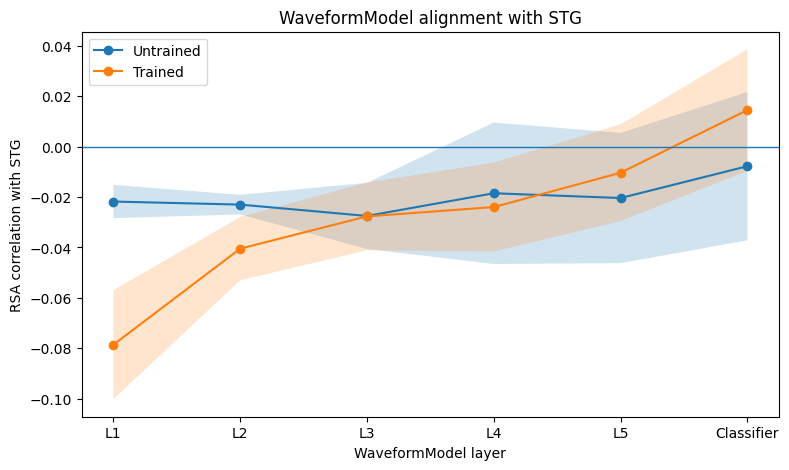

In [10]:
# put scores into run x layer arrays

layers = list(untrained_scores[0].keys())

untrained = np.array([
    [run[layer] for layer in layers]
    for run in untrained_scores
])

trained = np.array([
    [run[layer] for layer in layers]
    for run in trained_scores
])

print(untrained.shape)
print(trained.shape)

# mean and 95 confidence interval

for i, layer in enumerate(layers):
    u_mean, u_low, u_high = mean_ci(untrained[:, i])
    t_mean, t_low, t_high = mean_ci(trained[:, i])

    print(
        layer,
        "\nuntrained:", round(u_mean, 4),
        "[" + str(round(u_low, 4)) + ", " + str(round(u_high, 4)) + "]",
        "\ntrained:", round(t_mean, 4),
        "[" + str(round(t_low, 4)) + ", " + str(round(t_high, 4)) + "]\n"
    )

# trained vs untrained plot

u_mean = []
u_low = []
u_high = []

t_mean = []
t_low = []
t_high = []

for i in range(len(layers)):
    m, lo, hi = mean_ci(untrained[:, i])
    u_mean.append(m)
    u_low.append(lo)
    u_high.append(hi)

    m, lo, hi = mean_ci(trained[:, i])
    t_mean.append(m)
    t_low.append(lo)
    t_high.append(hi)

u_mean = np.array(u_mean)
u_low = np.array(u_low)
u_high = np.array(u_high)

t_mean = np.array(t_mean)
t_low = np.array(t_low)
t_high = np.array(t_high)

x = np.arange(len(layers))

plt.figure(figsize=(9, 5))

plt.plot(x, u_mean, marker="o", label="Untrained")
plt.fill_between(x, u_low, u_high, alpha=0.2)

plt.plot(x, t_mean, marker="o", label="Trained")
plt.fill_between(x, t_low, t_high, alpha=0.2)

plt.axhline(0, linewidth=1)

plt.xticks(
    x,
    ["L1", "L2", "L3", "L4", "L5", "Classifier"]
)

plt.xlabel("WaveformModel layer")
plt.ylabel("RSA correlation with STG")
plt.title("WaveformModel alignment with STG")
plt.legend()

plt.show()

euclidean distances rdms and pearson rsa shows us that the inital random weights untrained networks actually started of higher than the inital layers in the trained networks however, their is no clear depth-dependent trend. The trained network starts lower but shows clear improvement through each layer, ending up with a final postivie correlation  with a mean of 0.0145, however 0 is included in its 95 confidence interval so it should be interpreted with caution.

In [11]:
# alternative distance and correlation metrics

rdm_brain_corr = compute_rdm(brain, metric="correlation")

def get_rsa_scores_corr(model):
    activations = extract_activations(dataloader, model)
    scores = {}

    for layer, act in activations.items():
        rdm = compute_rdm(act.numpy(), metric="correlation")
        scores[layer] = compare_rdms(rdm_brain_corr, rdm, method="spearman")

    return scores

untrained_corr_scores = []

for seed in range(5):
    torch.manual_seed(seed)

    model = MODEL_CLASSES["waveform"](num_classes=50)
    scores = get_rsa_scores_corr(model)

    untrained_corr_scores.append(scores)

    print("\nuntrained", seed)
    for layer, score in scores.items():
        print(layer, round(score, 4))

trained_corr_scores = []

files = sorted(MODEL_DIR.glob("waveform_run*_best.pt"))

for file in files:
    model = MODEL_CLASSES["waveform"](num_classes=50)

    weights = torch.load(file, map_location="cpu")
    model.load_state_dict(weights)

    scores = get_rsa_scores_corr(model)
    trained_corr_scores.append(scores)

    print("\n", file.name)
    for layer, score in scores.items():
        print(layer, round(score, 4))

layers_corr = list(untrained_corr_scores[0].keys())

untrained_corr = np.array([
    [run[layer] for layer in layers_corr]
    for run in untrained_corr_scores
])

trained_corr = np.array([
    [run[layer] for layer in layers_corr]
    for run in trained_corr_scores
])

print(untrained_corr.shape)
print(trained_corr.shape)

for i, layer in enumerate(layers_corr):
    u_mean, u_low, u_high = mean_ci(untrained_corr[:, i])
    t_mean, t_low, t_high = mean_ci(trained_corr[:, i])

    print(
        layer,
        "\nuntrained:", round(u_mean, 4),
        "[" + str(round(u_low, 4)) + ", " + str(round(u_high, 4)) + "]",
        "\ntrained:", round(t_mean, 4),
        "[" + str(round(t_low, 4)) + ", " + str(round(t_high, 4)) + "]\n"
    )


untrained 0
hidden_layers.0 -0.0675
hidden_layers.1 -0.0972
hidden_layers.2 -0.0544
hidden_layers.3 -0.0573
hidden_layers.4 -0.0385
classifier -0.0088

untrained 1
hidden_layers.0 -0.0793
hidden_layers.1 -0.0867
hidden_layers.2 -0.0798
hidden_layers.3 -0.0615
hidden_layers.4 -0.0465
classifier -0.0429

untrained 2
hidden_layers.0 -0.0764
hidden_layers.1 -0.1177
hidden_layers.2 -0.1002
hidden_layers.3 -0.0893
hidden_layers.4 -0.0998
classifier -0.0609

untrained 3
hidden_layers.0 -0.0522
hidden_layers.1 -0.1059
hidden_layers.2 -0.0974
hidden_layers.3 -0.1033
hidden_layers.4 -0.0695
classifier -0.108

untrained 4
hidden_layers.0 -0.0436
hidden_layers.1 -0.0702
hidden_layers.2 -0.0821
hidden_layers.3 -0.0659
hidden_layers.4 -0.0058
classifier -0.0182


C:\Users\juras\AppData\Local\Temp\ipykernel_31308\1763452809.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(file, map_location="cpu")



 waveform_run0_best.pt
hidden_layers.0 -0.0464
hidden_layers.1 -0.0124
hidden_layers.2 -0.0098
hidden_layers.3 -0.0149
hidden_layers.4 -0.0061
classifier 0.0068

 waveform_run1_best.pt
hidden_layers.0 -0.0797
hidden_layers.1 -0.0394
hidden_layers.2 -0.0303
hidden_layers.3 -0.0235
hidden_layers.4 -0.0317
classifier -0.042

 waveform_run2_best.pt
hidden_layers.0 -0.0844
hidden_layers.1 -0.0404
hidden_layers.2 -0.0432
hidden_layers.3 -0.0418
hidden_layers.4 -0.0619
classifier -0.1125

 waveform_run3_best.pt
hidden_layers.0 -0.0703
hidden_layers.1 -0.018
hidden_layers.2 -0.0218
hidden_layers.3 -0.0219
hidden_layers.4 -0.0387
classifier -0.0322

 waveform_run4_best.pt
hidden_layers.0 -0.0604
hidden_layers.1 -0.0444
hidden_layers.2 -0.0472
hidden_layers.3 -0.0418
hidden_layers.4 -0.0293
classifier -0.02
(5, 6)
(5, 6)
hidden_layers.0 
untrained: -0.0638 [-0.083, -0.0446] 
trained: -0.0682 [-0.0872, -0.0492]

hidden_layers.1 
untrained: -0.0956 [-0.1181, -0.073] 
trained: -0.0309 [-0.0491, -0

layer01relu 0.0706
layer02relu 0.1039
layer03relu 0.1021
layer04relu 0.0817
layer05relu 0.0936
layer06relu 0.0915
layer07relu 0.1151
layer08relu 0.0976
layer09relu 0.0828
layer10relu 0.0029
layer11relu -0.1085
layer12relu -0.1183
layer13relu -0.0144
layer14relu -0.0108
embedding -0.0085


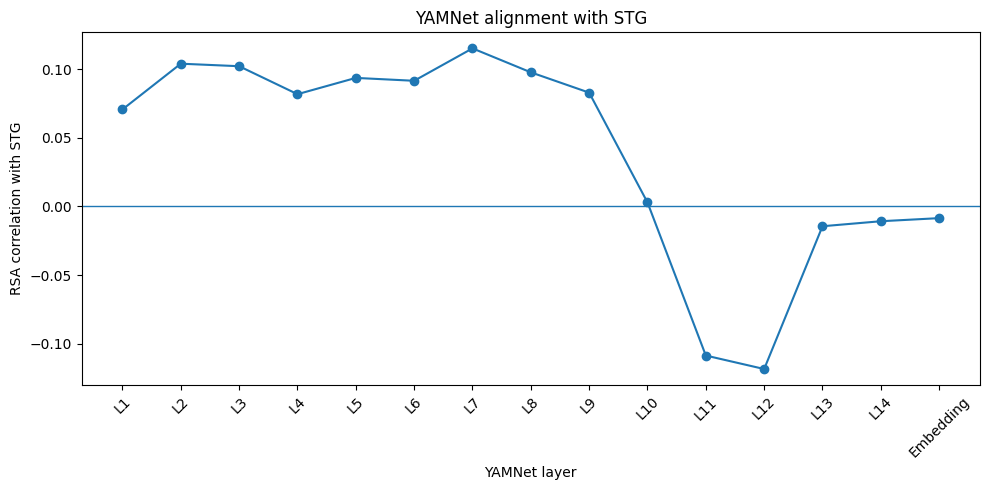

In [12]:
# YAMNet

yamnet_activations = load_yamnet_activations()

yamnet_scores = {}

for layer, act in yamnet_activations.items():
    rdm = compute_rdm(act, metric="euclidean")
    yamnet_scores[layer] = compare_rdms(
        rdm_brain,
        rdm,
        method="pearson"
    )

for layer, score in yamnet_scores.items():
    print(layer, round(score, 4))

# YAMNet layer alignment

yamnet_layers = list(yamnet_scores.keys())
yamnet_values = list(yamnet_scores.values())

x = np.arange(len(yamnet_layers))

plt.figure(figsize=(10, 5))
plt.plot(x, yamnet_values, marker="o")
plt.axhline(0, linewidth=1)

plt.xticks(
    x,
    [f"L{i}" for i in range(1, 15)] + ["Embedding"],
    rotation=45
)

plt.xlabel("YAMNet layer")
plt.ylabel("RSA correlation with STG")
plt.title("YAMNet alignment with STG")

plt.tight_layout()
plt.show()

in yamnet the allignment with stg peaked at layer 7 with r = 0.1151, and then it actually decreased. the final embedding layer showed r = -0.0085. this finding points to intermediate representations in yamnet being more similar to the type of representations measured in stg.

In [ ]:
# Comparisons, statistics and figures

# run x layer RSA arrays per model (euclidean RDMs, pearson); waveform reuses the arrays from above
results = {"waveform": {"untrained": untrained, "trained": trained}}

for name in ["uninspired", "inspired"]:

    runs = {"untrained": [], "trained": []}

    for run in range(5):
        torch.manual_seed(run)
        model = MODEL_CLASSES[name](num_classes=50)
        runs["untrained"].append(list(get_rsa_scores(model).values()))
        model.load_state_dict(torch.load(MODEL_DIR / f"{name}_run{run}_best.pt", map_location="cpu"))
        runs["trained"].append(list(get_rsa_scores(model).values()))
        
    results[name] = {cond: np.array(scores) for cond, scores in runs.items()}

C:\Users\juras\AppData\Local\Temp\ipykernel_31308\2819017281.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_DIR / f"{name}_run{r

In [ ]:
from scipy.stats import ttest_ind, f_oneway
from statsmodels.stats.multitest import multipletests

fmt = lambda s: "{:.4f} [{:.4f}, {:.4f}]".format(*mean_ci(s))

# training effect: Welch t-test trained vs untrained per model and layer, Holm-corrected over all tests
tests = [(n, l) for n, r in results.items() for l in range(r["trained"].shape[1])]
p_train = multipletests([ttest_ind(results[n]["trained"][:, l], results[n]["untrained"][:, l], equal_var=False).pvalue for n, l in tests], method="holm")[1]
for (n, l), p in zip(tests, p_train):
    print(f"{n:10s} L{l + 1}  untrained {fmt(results[n]['untrained'][:, l])}  trained {fmt(results[n]['trained'][:, l])}  p_holm = {p:.4f}")

# architecture effect: trained models compared at their best layer
best = {n: r["trained"][:, r["trained"].mean(0).argmax()] for n, r in results.items()}
print("\nANOVA, trained models at best layer:", f_oneway(*best.values()))
pairs = [("waveform", "uninspired"), ("waveform", "inspired"), ("uninspired", "inspired")]
p_arch = multipletests([ttest_ind(best[a], best[b], equal_var=False).pvalue for a, b in pairs], method="holm")[1]
for (a, b), p in zip(pairs, p_arch):
    print(f"{a} vs {b}: p_holm = {p:.4f}")

In [ ]:
# alternative metric for all models: correlation-distance RDMs, spearman; waveform reuses the arrays from cell 14
results_corr = {"waveform": {"untrained": untrained_corr, "trained": trained_corr}}

for name in ["uninspired", "inspired"]:
    runs = {"untrained": [], "trained": []}

    for run in range(5):
        torch.manual_seed(run)
        model = MODEL_CLASSES[name](num_classes=50)
        runs["untrained"].append(list(get_rsa_scores_corr(model).values()))
        model.load_state_dict(torch.load(MODEL_DIR / f"{name}_run{run}_best.pt", map_location="cpu"))
        runs["trained"].append(list(get_rsa_scores_corr(model).values()))

    results_corr[name] = {cond: np.array(scores) for cond, scores in runs.items()}
    
yamnet_scores_corr = {layer: compare_rdms(rdm_brain_corr, compute_rdm(act, "correlation"), "spearman") for layer, act in yamnet_activations.items()}

# best trained layer per model (mean [95% CI]) under both metrics: does the ranking hold?
for label, res, yam in [("euclidean / pearson", results, yamnet_scores), ("correlation / spearman", results_corr, yamnet_scores_corr)]:
    print(f"\n{label}")

    for n, r in res.items():
        l = r["trained"].mean(0).argmax()
        print(f"  {n:10s} best L{l + 1}: {fmt(r['trained'][:, l])}")

    print(f"  {'yamnet':10s} best {max(yam, key=yam.get)}: {max(yam.values()):.4f}")

C:\Users\juras\AppData\Local\Temp\ipykernel_31308\3258589323.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_DIR / f"{name}_run{ru


euclidean / pearson
  waveform   best L6: 0.0145 [-0.0096, 0.0386]
  uninspired best L2: 0.1009 [0.0877, 0.1141]
  inspired   best L2: 0.1134 [0.1028, 0.1239]
  yamnet     best layer07relu: 0.1151

correlation / spearman
  waveform   best L4: -0.0288 [-0.0441, -0.0135]
  uninspired best L5: 0.0330 [0.0262, 0.0397]
  inspired   best L5: 0.0547 [0.0417, 0.0677]
  yamnet     best layer12relu: 0.0980


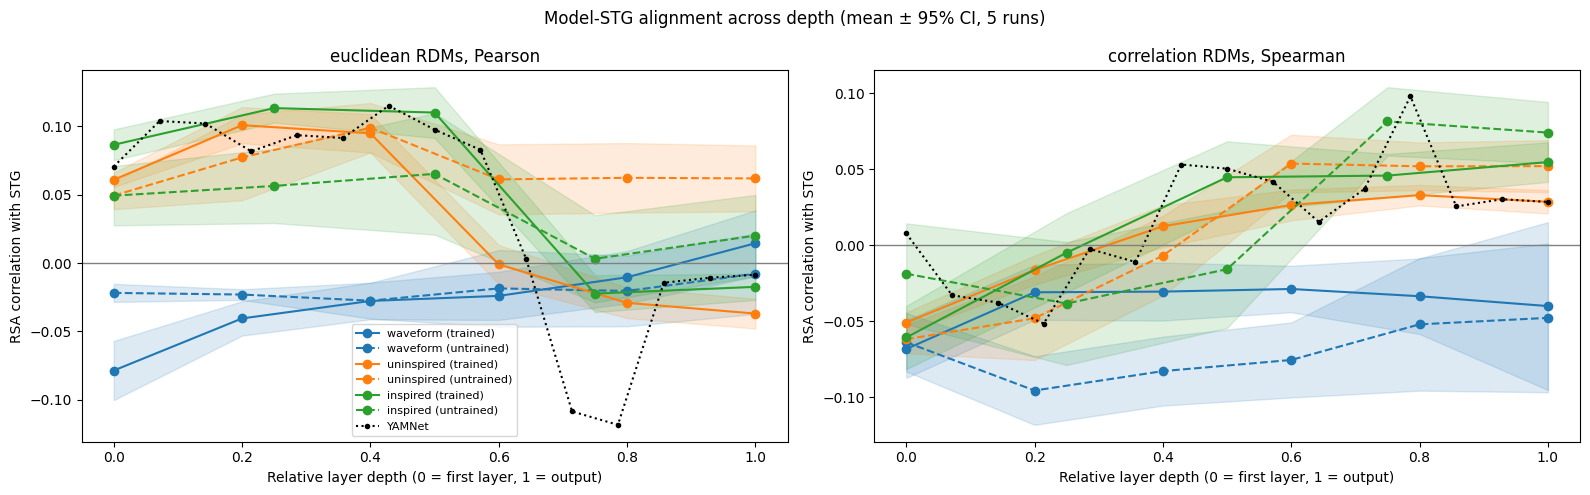

In [ ]:
# layer-depth plots for both metrics: mean +- 95% CI over 5 runs, depth normalised to 0-1 because layer counts differ
metrics = [(results, yamnet_scores, "euclidean RDMs, Pearson"), (results_corr, yamnet_scores_corr, "correlation RDMs, Spearman")]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (res, yam, metric) in zip(axes, metrics):

    for (n, r), color in zip(res.items(), ["C0", "C1", "C2"]):

        for cond, ls in [("trained", "-"), ("untrained", "--")]:

            m, lo, hi = np.array([mean_ci(col) for col in r[cond].T]).T
            x = np.linspace(0, 1, len(m))
            ax.plot(x, m, ls, color=color, marker="o", label=f"{n} ({cond})")
            ax.fill_between(x, lo, hi, color=color, alpha=0.15)

    ax.plot(np.linspace(0, 1, len(yam)), list(yam.values()), "k:", marker=".", label="YAMNet")
    ax.axhline(0, color="grey", linewidth=1)
    ax.set(xlabel="Relative layer depth (0 = first layer, 1 = output)", ylabel="RSA correlation with STG", title=metric)
    
axes[0].legend(fontsize=8)
fig.suptitle("Model-STG alignment across depth (mean ± 95% CI, 5 runs)")
plt.tight_layout()
plt.show()

## Part I — t-SNE of layer activations vs. brain

C:\Users\juras\AppData\Local\Temp\ipykernel_31308\3020518224.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_DIR / f"{name}_run0_

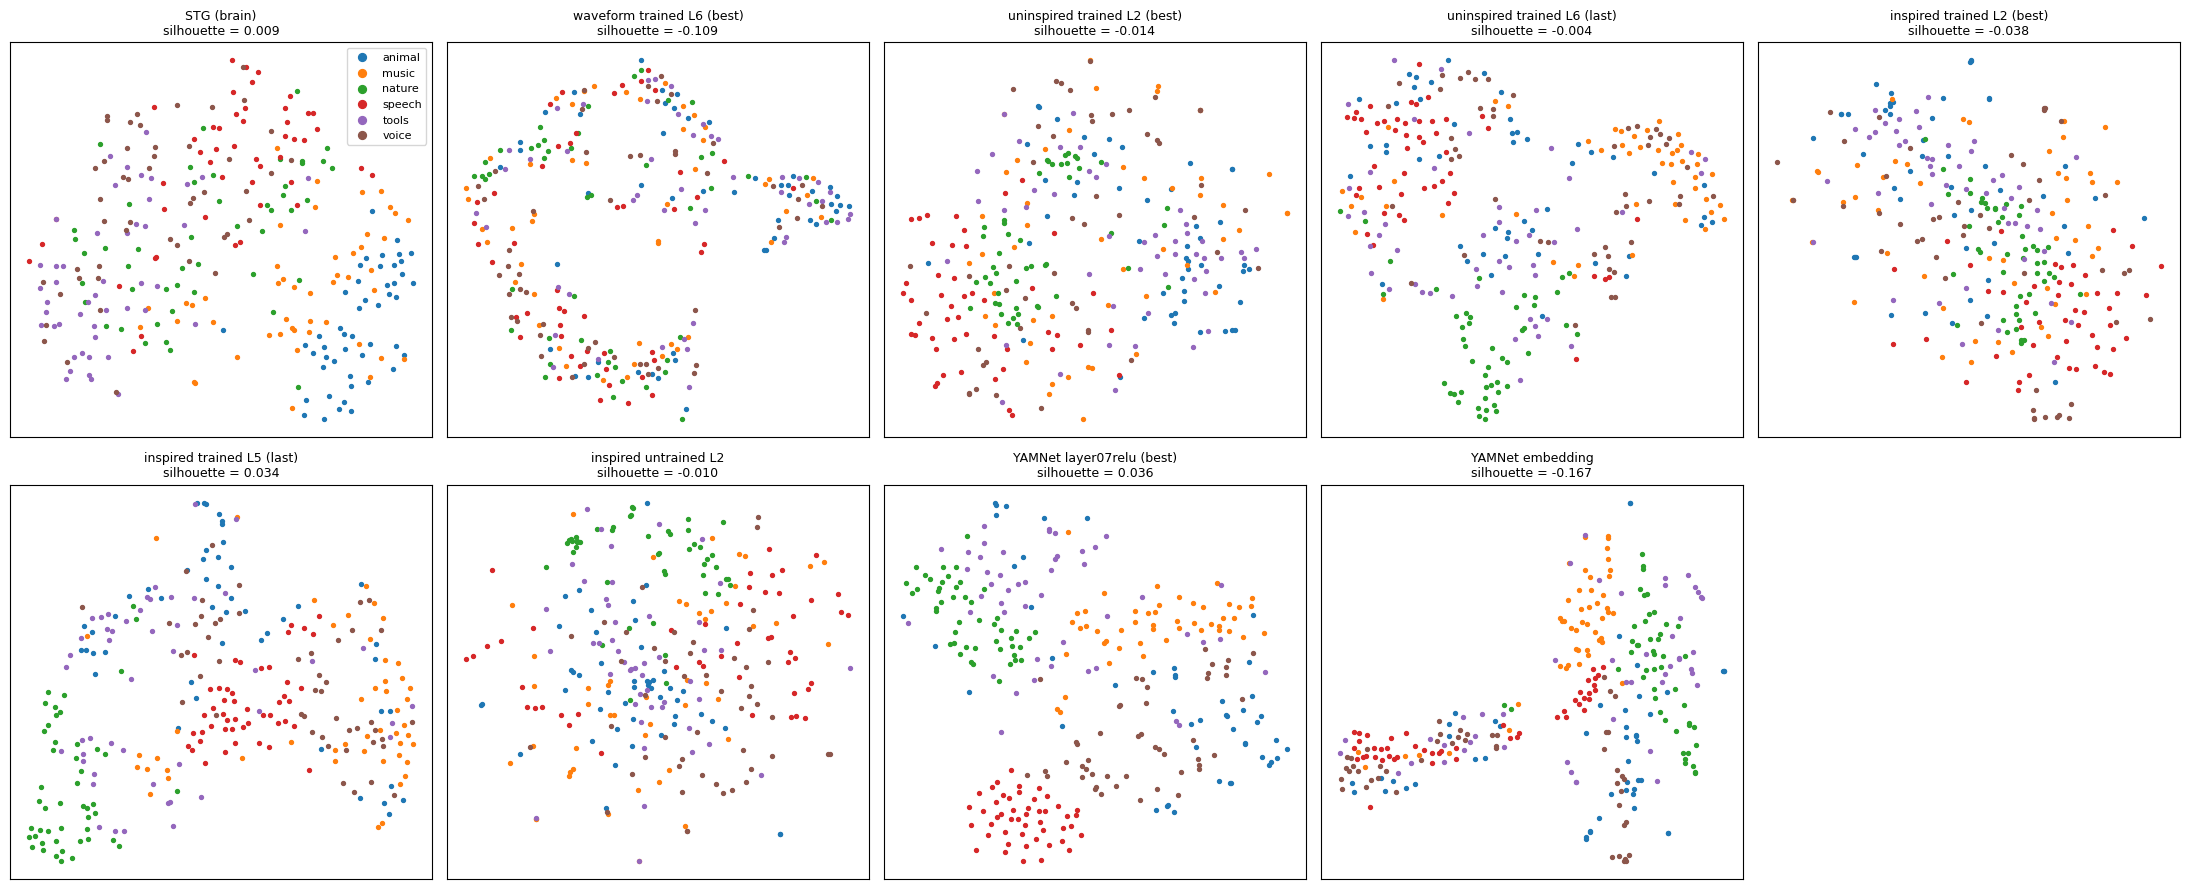

In [18]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

cats = np.array([f.split("_")[1] for f in dataset.filenames])  # 6 categories x 48 sounds: animal, music, nature, speech, tools, voice

def layer_acts(name, trained):
    """Flattened activations of every layer of run 0 of a model."""
    torch.manual_seed(0)
    model = MODEL_CLASSES[name](num_classes=50)

    if trained:
        model.load_state_dict(torch.load(MODEL_DIR / f"{name}_run0_best.pt", map_location="cpu"))

    return [act.numpy().reshape(len(act), -1) for act in extract_activations(dataloader, model).values()]

# brain, best (euclidean / pearson) + last layer of each trained model, untrained inspired, YAMNet best + embedding
panels = {"STG (brain)": brain}

for name, r in results.items():
    acts, l = layer_acts(name, trained=True), r["trained"].mean(0).argmax()
    panels[f"{name} trained L{l + 1} (best)"] = acts[l]

    if l != len(acts) - 1:
        panels[f"{name} trained L{len(acts)} (last)"] = acts[-1]

l = results["inspired"]["trained"].mean(0).argmax()
panels[f"inspired untrained L{l + 1}"] = layer_acts("inspired", trained=False)[l]
yamnet_best = max(yamnet_scores, key=yamnet_scores.get)
panels[f"YAMNet {yamnet_best} (best)"] = yamnet_activations[yamnet_best]
panels["YAMNet embedding"] = yamnet_activations["embedding"]

# silhouette is computed on the original activations (not the t-SNE map): higher = categories better separated
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for ax, (title, X) in zip(axes.flat, panels.items()):
    X = np.asarray(X).reshape(len(X), -1)
    emb = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(X)

    for c in np.unique(cats):
        ax.scatter(*emb[cats == c].T, s=8, label=c)

    ax.set_title(f"{title}\nsilhouette = {silhouette_score(X, cats):.3f}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(panels):]:
    ax.axis("off")

axes.flat[0].legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

## Part II (bonus) — own model